# Agentic segmentation pipeline

Grounding DINO → MedSAM loop reviewed by Gemma 4 E4B (multimodal, cloud).

Before running: set `GEMINI_API_KEY` in Colab Secrets (🔑 left pane).

In [1]:
# === Load models (cached across cell reruns) ========================
from agentic.dino_gemini_msd.models import get_dino_model, get_medsam_model, get_gemma_client

_ = get_dino_model()
_ = get_medsam_model()
gemma = get_gemma_client()
print('models ready')

/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \
/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loads checkpoint by local backend from path: /home/paulb/INF8225/Projet/work_dirs/tumor_config_v3/best_coco_bbox_mAP_epoch_11.pth


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmengine/runner/checkpoint.py:347: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(filena

models ready


In [2]:
# === Gemma smoke test (text + multimodal round-trip) ================
import json
from pathlib import Path
from agentic.dino_gemini_msd import config, medsam
from agentic.dino_gemini_msd.gemma import smoke_test

sample_img = next(config.MSD_IMAGES.rglob('*.png'))
image_np = medsam.load_image(str(sample_img))
print(json.dumps(smoke_test(gemma, image_np), indent=2))

{
  "refine": {
    "search_text": "pancreatic tumor",
    "synonyms": [
      "pancreas mass",
      "pancreatic lesion",
      "neoplasm"
    ]
  },
  "analyze": {
    "action": "replace_box",
    "params": {
      "box_2d": [
        545,
        442,
        658,
        605
      ]
    },
    "rationale": "The current mask is a large square covering multiple organs; it needs to be replaced with a tight bounding box around the hypodense tumor in the pancreatic head."
  }
}


[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['pancreatic tumor']


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/torch/utils/_contextlib.py:116: RuntimeWarning: Grounding DINO CUDA ops do not support bfloat16 in this environment; retrying in float32.
  return func(*args, **kwargs)
[nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['pancreatic tumor']


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'


[gemma] attempt 1/12 failed (ClientError); sleeping 45.0s


Traceback (most recent call last):
  File "/home/paulb/INF8225/Projet/agentic/dino_gemini_msd/gemma.py", line 352, in _retry
    result = fn()
             ^^^^
  File "/home/paulb/INF8225/Projet/agentic/dino_gemini_msd/gemma.py", line 209, in <lambda>
    lambda: self._client.models.generate_content(
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/google/genai/models.py", line 6276, in generate_content
    response = self._generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/google/genai/models.py", line 4730, in _generate_content
    response = self._api_client.request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/google/genai/_api_client.py", line 1537, in request
    response = self._request(http_request, http_options, stream=False)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^

run_id         : 2026-04-21T12-20-59-253
refined prompt : pancreatic tumor
stop reason    : rejected_add_positive
  iter 0: action=—              dice=0.0 area_pct=0.001
  iter 1: action=expand_box     dice=0.0 area_pct=0.002
  iter 2: action=replace_box    dice=0.0 area_pct=0.001


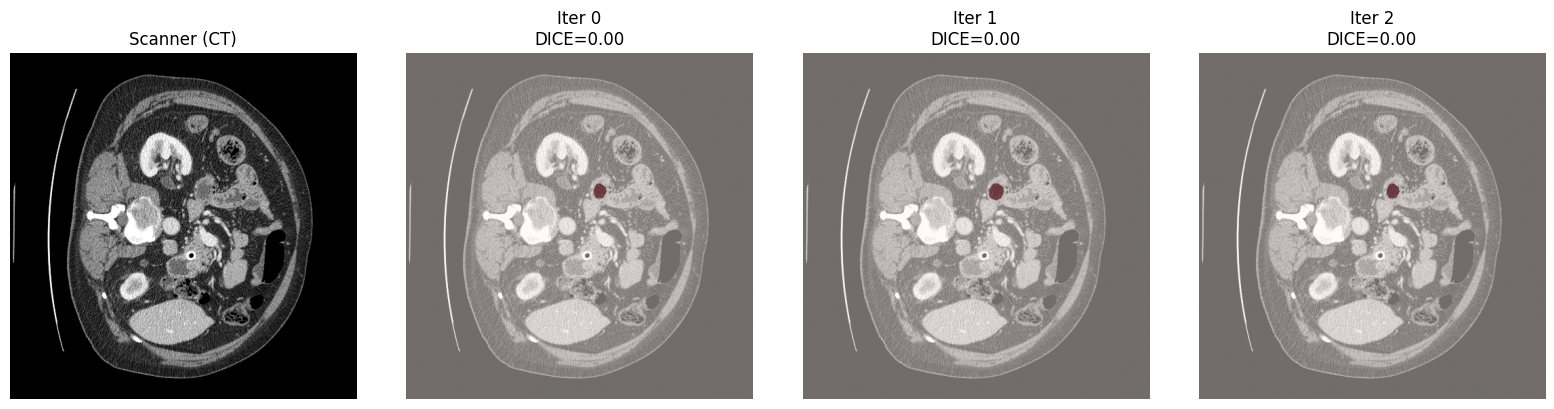

In [3]:
# === Single-image demo ==============================================
import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from agentic.dino_gemini_msd import config
from agentic.dino_gemini_msd.agent import run_agent

# 1. Sélection d'une image au hasard
demo_file = next(config.MSD_IMAGES.rglob('*.png'))

# 2. Déduction du chemin du masque (remplace 'images' par 'masks' dans le chemin)
mask_path_str = str(demo_file).replace("/images/", "/masks/")
gt_path = Path(mask_path_str)

gt = None
if gt_path.exists():
    m = io.imread(gt_path)
    # CRITIQUE : on isole la tumeur (valeur 2)
    gt = (m == 2).astype(np.uint8)

# 3. Lancement de l'Agent (Nouveau prompt)
state = run_agent(str(demo_file), 'find the pancreatic tumor', gt_mask=gt)

print(f'run_id         : {state.run_id}')
print(f'refined prompt : {state.refined_prompt}')
print(f'stop reason    : {state.stop_reason}')

for it in state.iterations:
    act = it.gemma_action.action if it.gemma_action else '—'
    print(f'  iter {it.iteration}: action={act:<14} '
          f'dice={it.dice_vs_gt} area_pct={it.metrics.area_pct:.3f}')

# 4. Affichage visuel
n = 1 + len(state.iterations)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4))

axes[0].imshow(state.image_np); axes[0].set_title('Scanner (CT)'); axes[0].axis('off')
for i, it in enumerate(state.iterations, start=1):
    axes[i].imshow(state.image_np)
    axes[i].imshow(it.mask, alpha=0.45, cmap='Reds')
    title_str = f'Iter {it.iteration}'
    if it.dice_vs_gt is not None:
        title_str += f'\nDICE={it.dice_vs_gt:.2f}'
    axes[i].set_title(title_str)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# === Batch evaluation on test.json ==================================
from agentic.dino_gemini_msd.eval import run_batch

df = run_batch(n=None)  # set n=None for the full test set
df.describe()[['first_iter_dice', 'final_dice', 'n_iterations']]

agentic:   0%|          | 0/100 [00:00<?, ?it/s][nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['pancreatic tumor']


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'


[gemma] analyze_mask fallback after AttributeError: returning stop


Traceback (most recent call last):
  File "/home/paulb/INF8225/Projet/agentic/dino_gemini_msd/gemma.py", line 338, in _retry
    result = fn()
             ^^^^
  File "/home/paulb/INF8225/Projet/agentic/dino_gemini_msd/gemma.py", line 208, in <lambda>
    raw = self._retry(
                ^^^^^^
  File "/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/google/genai/models.py", line 6276, in generate_content
    response = self._generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/google/genai/models.py", line 4730, in _generate_content
    response = self._api_client.request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/google/genai/_api_client.py", line 1537, in request
    response = self._request(http_request, http_options, stream=False)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paulb/INF8

...

noun_phrases: ['pancreatic tumor']


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
agentic:  20%|██        | 20/100 [03:32<10:39,  8.00s/it][nltk_data] Downloading package punkt to ~/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     ~/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


noun_phrases: ['pancreatic tumor']


/home/paulb/INF8225/Projet/.venv/lib/python3.11/site-packages/mmcv/cnn/bricks/transformer.py:524: UserWarning: position encoding of key ismissing in MultiheadAttention.
  warnings.warn(f'position encoding of key is'
agentic:  20%|██        | 20/100 [03:35<14:22, 10.78s/it]


KeyboardInterrupt: 

In [ ]:
# === One-shot vs agentic comparison =================================
from agentic.dino_gemini_msd.eval import compare_oneshot_vs_agentic

cmp_df = compare_oneshot_vs_agentic(n=None)
print(cmp_df[['one_shot_dice', 'agentic_dice', 'dice_delta']].describe())